# Analise Exploratoria dos Dados

## 1. Primeira Analise: BRASIL 

Mais geral e simples
Periodos de Janeiro de 2002 até dezembro de 2022 (10 anos)
Abrange território nacional como um todo

### Ler da BaseDeDados PIM_PF_BR_2006_2022

#### Limpar os dados e organizar

In [107]:
import pandas as pd
import os

caminho = os.path.join('..', 'BaseDeDados', 'PIM_PF_BR_2006_2022.csv')

#Pula as primeiras linhas do cabeçalho poluido
df = pd.read_csv(caminho, sep=';', encoding='utf-8', skiprows=3)
#print(df.head())

## O axis=1 Tira a primeira coluna, limpar dados sem utilidade
df = df.drop(df.columns[0], axis=1)
df = df.iloc[:2]
#print(df)

meses = {
    'janeiro': '01',
    'fevereiro': '02',
    'março': '03',
    'abril': '04',
    'maio': '05',
    'junho': '06',
    'julho': '07',
    'agosto': '08',
    'setembro': '09',
    'outubro': '10',
    'novembro': '11',
    'dezembro': '12'
}

novas_datas = []

for col in df.columns:
    try:
        mes, ano = col.split()
        mes_num = meses[mes.lower()]
        data = f"{mes_num}/{ano}"
        novas_datas.append(data)
    except:
        novas_datas.append(col)  # caso não seja mês

df.loc['Data'] = novas_datas
#print(df)

# 2. SALVANDO O TÍTULO ANALISE
# Pegamos o valor da primeira linha, primeira coluna
titulo_analise = df.iloc[0, 1]
#print (titulo_analise)

# 3. Remove a linha 1 (informação sem utilizade - "Indústria Geral") Pode ser o titulo da analise?
# O axis=0 diz que é uma LINHA
df = df.drop(index=0)
#print(df)
linha_data = df.loc[['Data']]
resto = df.drop(index='Data')


df = pd.concat([linha_data, resto])
print(df)


     janeiro 2002 fevereiro 2002 março 2002 abril 2002 maio 2002 junho 2002  \
Data      01/2002        02/2002    03/2002    04/2002   05/2002    06/2002   
1        72,39269       69,71441   77,39979   79,59671  80,44721   77,49757   

     julho 2002 agosto 2002 setembro 2002 outubro 2002  ... março 2022  \
Data    07/2002     08/2002       09/2002      10/2002  ...    03/2022   
1      83,26465    83,58971      82,11028     89,17857  ...   84,49285   

     abril 2022 maio 2022 junho 2022 julho 2022 agosto 2022 setembro 2022  \
Data    04/2022   05/2022    06/2022    07/2022     08/2022       09/2022   
1      80,88910  88,83537   87,51774   91,95659    95,95352      91,81049   

     outubro 2022 novembro 2022 dezembro 2022  
Data      10/2022       11/2022       12/2022  
1        91,26549      87,03596      78,21171  

[2 rows x 252 columns]


#### Plotar os dados ano a ano

        Data    indice
0    01/2002  72.39269
1    02/2002  69.71441
2    03/2002  77.39979
3    04/2002  79.59671
4    05/2002  80.44721
..       ...       ...
247  08/2022  95.95352
248  09/2022  91.81049
249  10/2022  91.26549
250  11/2022  87.03596
251  12/2022  78.21171

[252 rows x 2 columns]
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


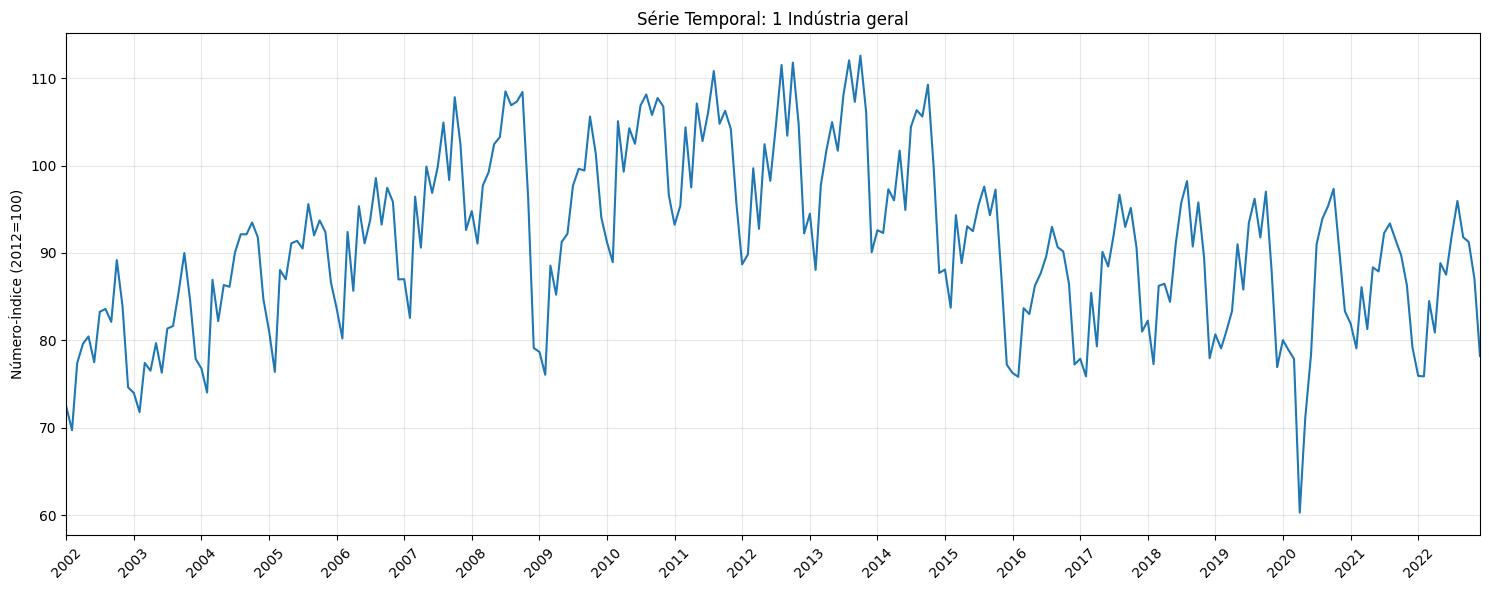

In [108]:
# TRANSPOSIÇÃO E CONVERSÃO
df_final = pd.DataFrame({
    'Data': df.iloc[0].values,
    'indice': df.iloc[1].values
})

df_final = df_final.dropna()

df_final['indice'] = (
    df_final['indice']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)


print(df_final)
df_final['Data'] = pd.to_datetime(df_final['Data'], format='%m/%Y')
df_final = df_final.set_index('Data')
print(type(df_final.index))


# 7. GRÁFICO USANDO O TÍTULO SALVO
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Aumentamos um pouco o gráfico para caber mais informação
fig, ax = plt.subplots(figsize=(15, 6))

# Plotamos os dados
ax.plot(df_final.index, df_final['indice'], label='Índice de Produção', color='tab:blue')

# --- O PULO DO GATO ESTÁ AQUI ---
# 1. Força o marcador a aparecer de 1 em 1 ano (YearLocator(1))
ax.xaxis.set_major_locator(mdates.YearLocator(1)) 

# 2. Formata para mostrar apenas o Ano
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3. Inclina 45 graus para os anos não baterem um no outro
plt.xticks(rotation=45)


plt.xlim(df_final.index.min(), df_final.index.max())

plt.title(f'Série Temporal: {titulo_analise}')
plt.ylabel('Número-Índice (2012=100)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Plotar para o ano de 2012

        Data    indice
0    01/2002  72,39269
1    02/2002  69,71441
2    03/2002  77,39979
3    04/2002  79,59671
4    05/2002  80,44721
..       ...       ...
247  08/2022  95,95352
248  09/2022  91,81049
249  10/2022  91,26549
250  11/2022  87,03596
251  12/2022  78,21171

[252 rows x 2 columns]


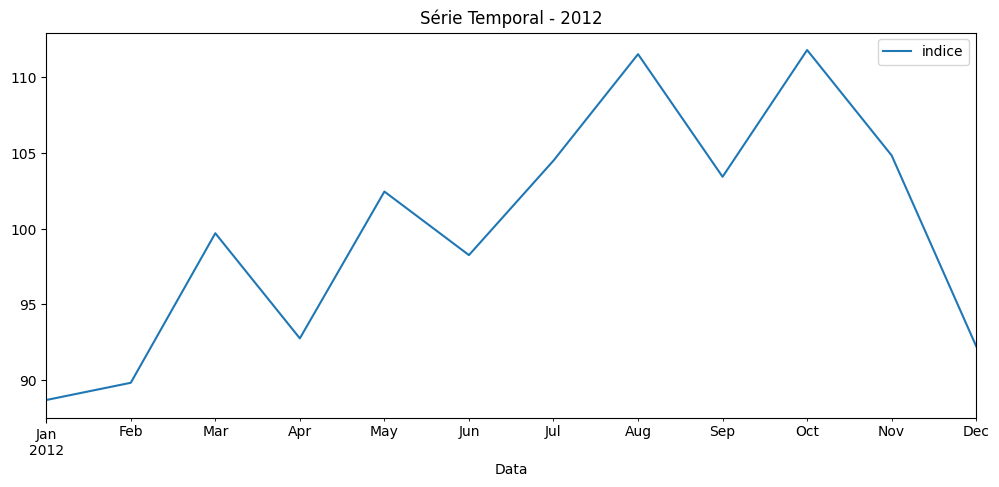

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
df_2012 = pd.DataFrame({
    'Data': df.iloc[0].values,
    'indice': df.iloc[1].values
})

print(df_2012)


df_2012 = df_2012.dropna()

df_2012['indice'] = (
    df_2012['indice']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

df_2012['Data'] = pd.to_datetime(df_2012['Data'], format='%m/%Y')
df_2012 = df_2012.set_index('Data')
#print(df_final)
df_2012 = df_final.loc['2012']
df_2012.plot(figsize=(12,5))
plt.title('Série Temporal - 2012')
plt.show()

### Vamos fazer a EDA

#### Tendencia

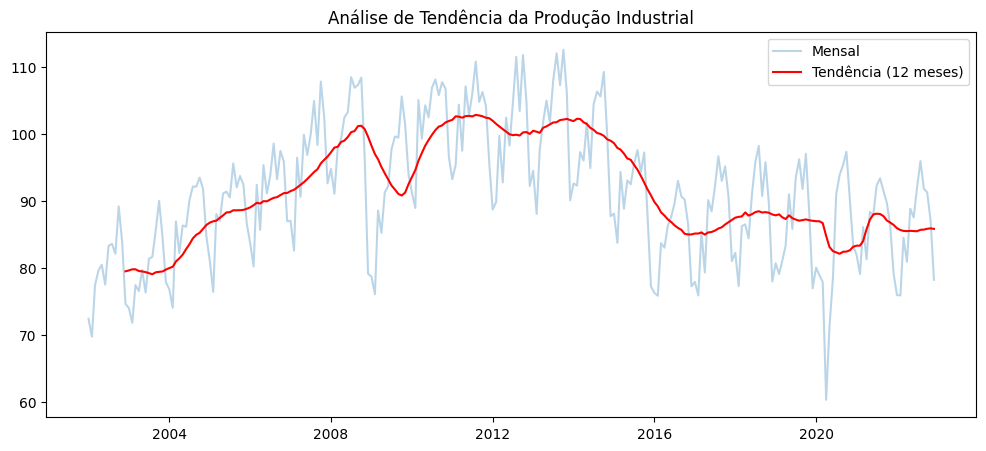

In [112]:
# Média móvel de 12 meses (uma janela de 1 ano)
df_final['media_movel'] = df_final['indice'].rolling(window=12).mean()

plt.figure(figsize=(12,5))
plt.plot(df_final.index, df_final['indice'], alpha=0.3, label='Mensal')
plt.plot(df_final.index, df_final['media_movel'], color='red', label='Tendência (12 meses)')
plt.title('Análise de Tendência da Produção Industrial')
plt.legend()
plt.show()

#### Sazonalidade

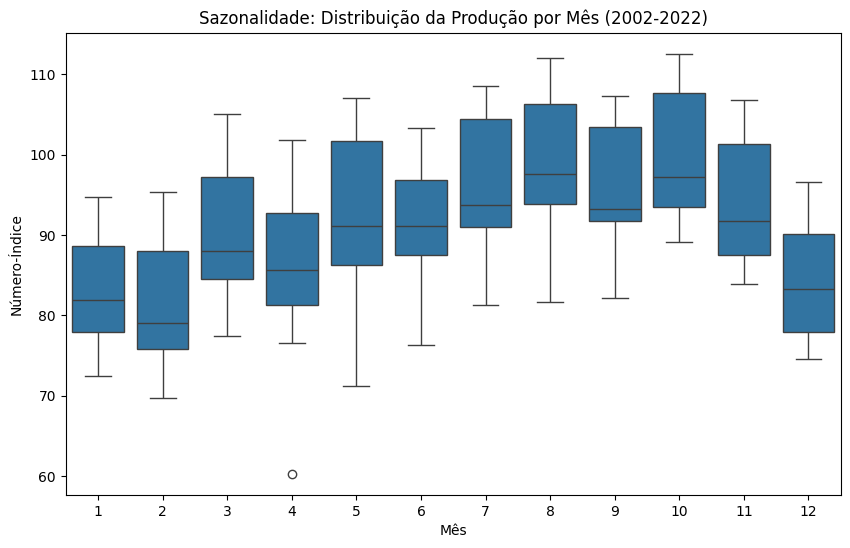

In [113]:
import seaborn as sns

# Extrair o mês para uma nova coluna
df_final['Mes_Num'] = df_final.index.month

plt.figure(figsize=(10,6))
sns.boxplot(x='Mes_Num', y='indice', data=df_final)
plt.title('Sazonalidade: Distribuição da Produção por Mês (2002-2022)')
plt.xlabel('Mês')
plt.ylabel('Número-Índice')
plt.show()

Tem sazonalidade... pico é em outubro novembro... e o vale no começo do ano.. Tem um outiliers no mes quadro... deve ser da pandemia...

#### Estacionaria a Serie?

In [ ]:
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df_final['indice'])
print(f'P-valor do Teste ADF: {resultado_adf[1]}')

# Se p-valor > 0.05, a série nao e estacionária (tem tendência)
# Se p-valor <= 0.05, a série e estacionária

P-valor do Teste ADF: 0.2370280896875011


#### 3. Ruido!

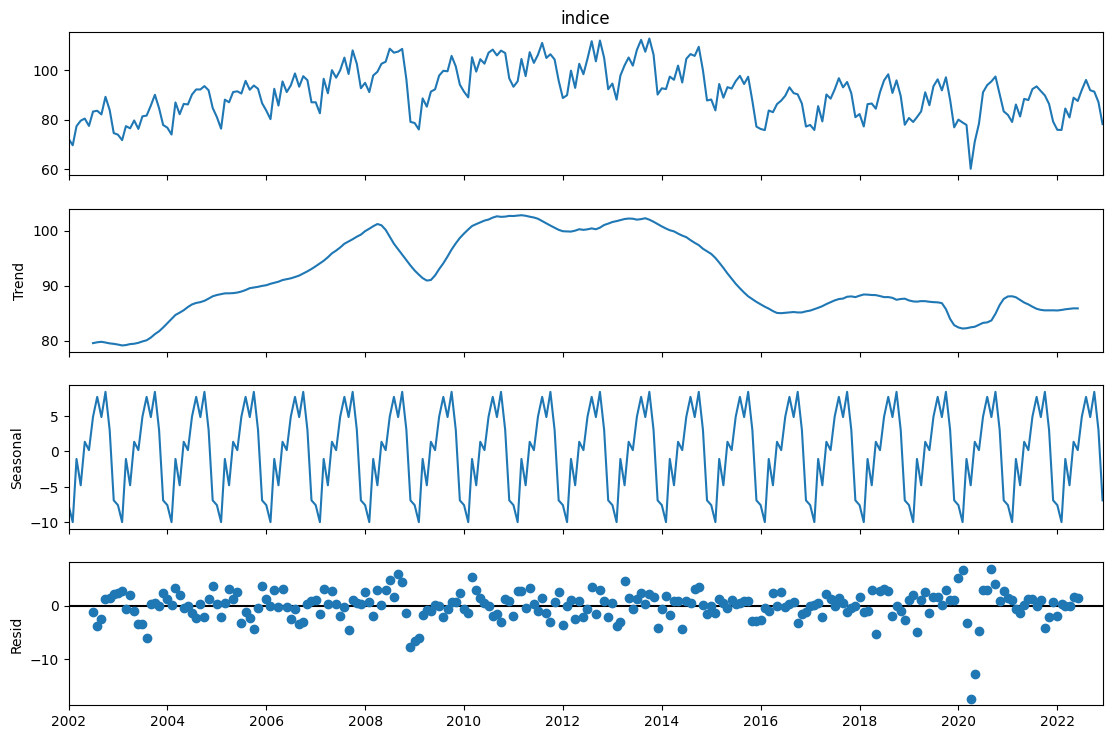

In [115]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposição Aditiva (porque a oscilação parece constante)
decomposicao = seasonal_decompose(df_final['indice'], model='additive', period=12)

# Plotar os 4 gráficos de uma vez
fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.show()

Em 2020 teve bastante ruido... pandemia. mas entre 2008-2010 também teve alguma coisa